# Stage 3: Dual-Token Fusion Deepfake Detection
This notebook presents the pretraining stage of the final deepfake detection model. The model combines spatial RGB features and frequency-aware features using a dual-token fusion strategy with a Transformer encoder. At this stage, the objective is detection only, not localisation.


## 1. Import Libraries and Set Up Environment
This section imports all required libraries for preprocessing, model development, training, and evaluation. It also sets up the runtime environment and warnings configuration.


In [1]:
# ============================================
# Stage 3 – Dual-Token Fusion (RGB + FFT on Input)
# Full fine-tuning with DeepfakeBench metrics
# ============================================

import os, random, torch, torch.nn as nn, torch.optim as optim
import numpy as np
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.fft as fft
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from PIL import Image
from io import BytesIO
import warnings
import torch.nn.functional as F
warnings.filterwarnings("ignore")





In [2]:
!pip install facenet-pytorch --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 37.1 MB/s eta 0:00:00


## 2. Face Alignment Preprocessing
Before training, all images are aligned using MTCNN. This step standardises facial position and scale so that the model learns manipulation cues rather than background or pose variation. If no face is detected, the original image is resized and used as a fallback.


In [3]:
from facenet_pytorch import MTCNN
from PIL import Image
import os
from tqdm import tqdm
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

mtcnn = MTCNN(
    image_size=224,
    margin=40,          # prevents chin/forehead cuts
    device=device,
    post_process=False
)

SRC_ROOT = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake"
DST_ROOT = "/kaggle/working/140k_aligned_faces"

splits = ["train", "valid", "test"]
classes = ["real", "fake"]

for split in splits:
    for cls in classes:
        src_dir = os.path.join(SRC_ROOT, split, cls)
        dst_dir = os.path.join(DST_ROOT, split, cls)
        os.makedirs(dst_dir, exist_ok=True)

        files = os.listdir(src_dir)

        for f in tqdm(files, desc=f"{split}/{cls}"):

            src_path = os.path.join(src_dir, f)
            dst_path = os.path.join(dst_dir, f)

            try:
                img = Image.open(src_path).convert("RGB")

                face = mtcnn(img)

                if face is None:
                    # fallback: just resize original
                    img = img.resize((224,224))
                    img.save(dst_path)
                else:
                    face = face.permute(1,2,0).byte().numpy()
                    Image.fromarray(face).save(dst_path)

            except:
                continue

test/fake: 100%|██████████| 10000/10000 [06:18<00:00, 26.45it/s]


The aligned dataset is saved to `/kaggle/working/140k_aligned_faces` and used for all subsequent training, validation, and test splits.


## 3. Dataset Construction and Augmentation
This section defines the training, validation, and test datasets using aligned face images. Two views are produced for each sample:
- an RGB view for spatial feature learning
- a raw image view for frequency-related processing

Data augmentation includes horizontal flipping, JPEG recompression, and mild colour jitter to improve robustness.


In [4]:
import torchvision.transforms.functional as TF

class DualViewImageFolder(datasets.ImageFolder):
    def __init__(self, root, p_flip=0.5, jpeg_aug=None,
                 rgb_color_aug=None, rgb_norm=None):
        super().__init__(root, transform=None)
        self.p_flip = p_flip
        self.jpeg_aug = jpeg_aug
        self.rgb_color_aug = rgb_color_aug
        self.rgb_norm = rgb_norm

    def __getitem__(self, index):
        path, y = self.samples[index]
        img = self.loader(path).convert("RGB")

        # ---- shared geometry ----
    
        if random.random() < self.p_flip:
            img = TF.hflip(img)

        # ---- shared JPEG (optional but recommended) ----
        if self.jpeg_aug is not None:
            img_jpeg = self.jpeg_aug(img)
        else:
            img_jpeg = img

        # ---- RAW view (for FFT): no normalize ----
        x_raw = TF.to_tensor(img_jpeg)  # [0,1]

        # ---- RGB view: color aug + normalize ----
        img_rgb = img_jpeg
        if self.rgb_color_aug is not None:
            img_rgb = self.rgb_color_aug(img_rgb)

        x_rgb = TF.to_tensor(img_rgb)
        if self.rgb_norm is not None:
            x_rgb = self.rgb_norm(x_rgb)

        return x_rgb, x_raw, y

## 4. Evaluation Metrics
Model performance is evaluated using DeepfakeBench-style metrics:
- AUROC
- F1-score
- Accuracy
- EER (Equal Error Rate)

These metrics provide a balanced view of classification quality and threshold-based behaviour.


In [5]:
# ---- DeepfakeBench metric helper ----
def calc_metrics(y_true, y_prob):
    y_pred = (y_prob > 0.5).astype(int)
    auc  = roc_auc_score(y_true, y_prob)
    f1   = f1_score(y_true, y_pred)
    acc  = accuracy_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    eer  = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    return auc, f1, eer, acc

## 5. Model Architecture
The proposed Stage 3 model uses a dual-token fusion design:
- RGB tokens are extracted from high-level spatial feature maps
- FFT-inspired frequency tokens are derived from a learnable global frequency filter
- cross-attention allows RGB tokens to attend to frequency tokens
- a Transformer encoder fuses both streams for final classification

This design aims to capture both visual appearance and manipulation-related frequency artifacts.


In [6]:
from io import BytesIO
from PIL import Image
import random

class RandomJPEG:
    def __init__(self, quality_min=30, quality_max=100, p=0.7):
        self.quality_min = quality_min
        self.quality_max = quality_max
        self.p = p

    def __call__(self, img: Image.Image):
        if random.random() > self.p:
            return img
        q = random.randint(self.quality_min, self.quality_max)
        buf = BytesIO()
        img.save(buf, format="JPEG", quality=q)
        buf.seek(0)
        return Image.open(buf).convert("RGB")

### 5.1 Frequency Branch
A learnable global filter is applied in the frequency domain to capture manipulation traces that may not be obvious in RGB appearance alone.


In [7]:
class GlobalFilter(nn.Module):
    """
    Learnable complex filter applied in frequency domain.
    Expects fixed H,W feature map size (e.g., 28x28).
    """
    def __init__(self, dim, h, w, fp32fft=True):
        super().__init__()
        self.h = h
        self.w = w
        self.fp32fft = fp32fft

        # rfft2 width is (w//2 + 1)
        self.complex_weight = nn.Parameter(
            torch.randn(h, w // 2 + 1, dim, 2, dtype=torch.float32) * 0.02
        )

    def forward(self, x):
        # x: [B,C,H,W] where H,W match self.h,self.w
        B, C, H, W = x.shape
        assert H == self.h and W == self.w, f"Expected {self.h}x{self.w}, got {H}x{W}"

        x = x.permute(0, 2, 3, 1).contiguous()  # [B,H,W,C]

        if self.fp32fft:
            orig_dtype = x.dtype
            x = x.float()

        x_f = torch.fft.rfft2(x, dim=(1, 2), norm="ortho")  # [B,H,W//2+1,C]
        w = torch.view_as_complex(self.complex_weight)      # [H,W//2+1,C]
        x_f = x_f * w

        x = torch.fft.irfft2(x_f, s=(H, W), dim=(1, 2), norm="ortho")  # [B,H,W,C]

        if self.fp32fft:
            x = x.to(orig_dtype)

        x = x.permute(0, 3, 1, 2).contiguous()  # [B,C,H,W]
        return x

### 5.2 Dual-Token Fusion Network
The model combines ResNet-50 feature extraction, RGB-frequency token fusion, cross-attention, and Transformer-based global reasoning for fake/real classification.


In [8]:
class Stage3Hybrid(nn.Module):
    def __init__(self, embed_dim=512, num_heads=8, num_layers=4, use_fft=True, grid=10):
        super().__init__()
        self.use_fft = use_fft
        self.grid = grid
        self.freq_filter = GlobalFilter(dim=512, h=28, w=28, fp32fft=True)

        # --backbone--
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

           # split resnet into stages
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2   # -> [B,512,28,28] for 224 input
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4   # -> [B,2048,7,7]
        
            # RGB tokens from layer4 (same spirit as before)
        self.proj_rgb = nn.Conv2d(2048, embed_dim, 1)
        
           # FREQ tokens will come from layer2 (512 channels)
        self.proj_fft = nn.Conv2d(512, embed_dim, 1)

        
        # ---- Cross-Modality Fusion (RGB attends to FFT) ----
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)

        # ---- Transformer encoder ----
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        # ---- tokens ----
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.type_embed = nn.Parameter(torch.randn(1, 2, embed_dim))  # 0=RGB, 1=FFT

        # positions: 1 CLS + 2*(grid*grid)
        num_tokens = 1 + 2 * (grid * grid)
        self.pos_embed = nn.Parameter(torch.randn(1, num_tokens, embed_dim))

        # classifier
        self.cls_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 2)
        )
   
   
    def forward(self, x_rgb, x_raw=None):
        B = x_rgb.size(0)
    
        # ---- run ResNet stages ----
        x = self.stem(x_rgb)
        x = self.layer1(x)
        feat_l2 = self.layer2(x)        # [B,512,28,28]  <-- use this for freq branch
    
        x = self.layer3(feat_l2)
        feat_l4 = self.layer4(x)        # [B,2048,7,7]   <-- use this for rgb branch
    
        # ---- RGB tokens ----
        rgb_map = self.proj_rgb(feat_l4)                       # [B,E,7,7]
        rgb_map = F.adaptive_avg_pool2d(rgb_map, (self.grid, self.grid))
        rgb_tok = rgb_map.flatten(2).transpose(1, 2)           # [B,G^2,E]
    
        # ---- FREQ tokens (M2TR-style learned filter on feature map) ----
        if self.use_fft:
            freq_feat = self.freq_filter(feat_l2)              # [B,512,28,28]
            fft_map = self.proj_fft(freq_feat)                 # [B,E,28,28]
            fft_map = F.adaptive_avg_pool2d(fft_map, (self.grid, self.grid))
            fft_tok = fft_map.flatten(2).transpose(1, 2)       # [B,G^2,E]
        else:
            fft_tok = torch.zeros_like(rgb_tok)
    
        # ---- type embeds ----
        rgb_tok = rgb_tok + self.type_embed[:, 0:1, :]
        fft_tok = fft_tok + self.type_embed[:, 1:2, :]
    
        # ---- Cross-attn fusion ----
        fused_rgb, _ = self.cross_attn(query=rgb_tok, key=fft_tok, value=fft_tok)
        rgb_tok = rgb_tok + fused_rgb
    
        # ---- tokens + transformer ----
        cls = self.cls_token.repeat(B, 1, 1)
        tokens = torch.cat([cls, rgb_tok, fft_tok], dim=1)
        tokens = tokens + self.pos_embed[:, :tokens.size(1), :]
    
        out = self.transformer(tokens)
        cls_out = out[:, 0]
        return self.cls_head(cls_out)


## 6. Training Configuration
The model is trained using full fine-tuning. A lower learning rate is used for the ResNet backbone and a higher learning rate is used for newly introduced fusion and classification layers. Cosine annealing is applied to gradually reduce the learning rate across epochs.


In [9]:
from torch.optim.lr_scheduler import CosineAnnealingLR

def train_stage3():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = Stage3Hybrid().to(device)

    # ---- Dataset ----
    jpeg_aug = RandomJPEG(quality_min=30, quality_max=100, p=0.7)
    

    rgb_color_aug = transforms.Compose([
        transforms.ColorJitter(0.1, 0.1, 0.05, 0.02),
    ])

    rgb_norm = transforms.Normalize([0.485, 0.456, 0.406],
                                    [0.229, 0.224, 0.225])

    trainset = DualViewImageFolder(
        "/kaggle/working/140k_aligned_faces/train",
        p_flip=0.5, jpeg_aug=jpeg_aug, rgb_color_aug=rgb_color_aug, rgb_norm=rgb_norm
    )
    valset = DualViewImageFolder(
        "/kaggle/working/140k_aligned_faces/valid",
        p_flip=0.0, jpeg_aug=None, rgb_color_aug=None, rgb_norm=rgb_norm
    )
    testset = DualViewImageFolder(
        "/kaggle/working/140k_aligned_faces/test",
        p_flip=0.0, jpeg_aug=None, rgb_color_aug=None, rgb_norm=rgb_norm
    )

    trainloader = DataLoader(trainset, batch_size=16, shuffle=True, num_workers=0)
    valloader   = DataLoader(valset, batch_size=16, shuffle=False, num_workers=2)
    testloader  = DataLoader(testset, batch_size=16, shuffle=False, num_workers=2)

    class_to_idx = trainset.class_to_idx
    print("class_to_idx:", class_to_idx)

    # ---- Optimiser / loss / scaler ----
    backbone_params = (
        list(model.stem.parameters())
        + list(model.layer1.parameters())
        + list(model.layer2.parameters())
        + list(model.layer3.parameters())
        + list(model.layer4.parameters())
    )
    head_params = [
        p for n, p in model.named_parameters()
        if not (n.startswith("stem.") or n.startswith("layer1.") or n.startswith("layer2.")
                or n.startswith("layer3.") or n.startswith("layer4."))
    ]

    opt = optim.AdamW(
        [
            {"params": backbone_params, "lr": 1e-5},
            {"params": head_params,     "lr": 1e-4},
        ],
        weight_decay=1e-4
    )

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    epochs = 10
    best_auc = 0.0

    scheduler = CosineAnnealingLR(opt, T_max=epochs)

    use_cuda = torch.cuda.is_available()
    scaler = torch.amp.GradScaler(enabled=use_cuda)

    fake_idx = class_to_idx["fake"]  # define once
    # ---- store training history for plots ----
    train_loss_list = []
    val_auc_list = []
    val_f1_list = []
    val_acc_list = []
    val_eer_list = []
    lr_backbone_list = []
    lr_head_list = []


    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        running_loss = 0.0

        for x_rgb, x_raw, lbls in tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs}", ncols=100):
            x_rgb = x_rgb.to(device, non_blocking=True)
            x_raw = x_raw.to(device, non_blocking=True)
            lbls  = lbls.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type="cuda", enabled=use_cuda):
                logits = model(x_rgb, x_raw)
                loss = criterion(logits, lbls)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

            running_loss += loss.item()

        # ---- Validation ----
        model.eval()
        y_true, y_prob = [], []

        with torch.no_grad():
            for x_rgb, x_raw, lbls in valloader:
                x_rgb = x_rgb.to(device, non_blocking=True)
                x_raw = x_raw.to(device, non_blocking=True)

                logits = model(x_rgb, x_raw)
                probs_fake = torch.softmax(logits, dim=1)[:, fake_idx].cpu().numpy()

                lbls_np = lbls.numpy()
                y_true.extend((lbls_np == fake_idx).astype(np.int32))
                y_prob.extend(probs_fake)

      
        auc, f1, eer, acc = calc_metrics(np.array(y_true), np.array(y_prob))

        train_loss_list.append(running_loss / len(trainloader))
        val_auc_list.append(auc)
        val_f1_list.append(f1)
        val_acc_list.append(acc)
        val_eer_list.append(eer)
        lr_backbone_list.append(opt.param_groups[0]["lr"])
        lr_head_list.append(opt.param_groups[1]["lr"])

        print(f"Epoch {epoch+1}: loss={running_loss/len(trainloader):.4f} | "
              f"AUROC={auc:.3f} | F1={f1:.3f} | EER={eer:.3f} | ACC={acc:.3f}")

        scheduler.step()
        print("LRs:", [pg["lr"] for pg in opt.param_groups])


        ckpt_path = f"/kaggle/working/stage3_epoch{epoch+1}.pth"
        torch.save(model.state_dict(), ckpt_path)

        if auc > best_auc:
            best_auc = auc
            torch.save(model.state_dict(), "/kaggle/working/best_auc_stage3.pth")
            print(f"New best AUC {best_auc:.3f} (ACC={acc:.3f})")

    print("\nTraining complete!")
    print(f"Best model achieved: AUROC={best_auc:.3f}")
    return (
        model,
        testloader,
        class_to_idx,
        train_loss_list,
        val_auc_list,
        val_f1_list,
        val_acc_list,
        val_eer_list,
        lr_backbone_list,
        lr_head_list,
    )


In [10]:
def evaluate(model, loader, class_to_idx, tag="TEST"):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()

    fake_idx = class_to_idx["fake"]   # positive class = fake
    y_true, y_prob = [], []

    with torch.no_grad():
        for x_rgb, x_raw, lbls in tqdm(loader, desc=tag, ncols=100):
            x_rgb = x_rgb.to(device, non_blocking=True)
            x_raw = x_raw.to(device, non_blocking=True)

            logits = model(x_rgb, x_raw)
            probs_fake = torch.softmax(logits, dim=1)[:, fake_idx].cpu().numpy()

            # y_true must be 1 for fake, 0 for real
            lbls_np = lbls.numpy()
            y_true.extend((lbls_np == fake_idx).astype(np.int32))
            y_prob.extend(probs_fake)

    auc, f1, eer, acc = calc_metrics(np.array(y_true), np.array(y_prob))
    print(f"{tag} → AUROC={auc:.3f} | F1={f1:.3f} | EER={eer:.3f} | ACC={acc:.3f}")
    return auc, f1, eer, acc



## 7. Model Training and Validation
This section trains the model for 10 epochs and evaluates it on the validation set after each epoch. The best-performing checkpoint is selected based on validation AUROC.

 After training, the best validation checkpoint is reloaded and evaluated on the held-out 140k test set to measure final generalisation performance.



In [11]:
if __name__ == "__main__":
    (
        model,
        testloader,
        class_to_idx,
        train_loss_list,
        val_auc_list,
        val_f1_list,
        val_acc_list,
        val_eer_list,
        lr_backbone_list,
        lr_head_list,
    ) = train_stage3()


    # Load best validation model before testing
    model.load_state_dict(torch.load("/kaggle/working/best_auc_stage3.pth"))

    evaluate(model, testloader, class_to_idx, tag="140k TEST")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 221MB/s]


class_to_idx: {'fake': 0, 'real': 1}


Epoch 1/10: 100%|███████████████████████████████████████████████| 6250/6250 [25:35<00:00,  4.07it/s]


Epoch 1: loss=0.3510 | AUROC=0.995 | F1=0.966 | EER=0.034 | ACC=0.966
LRs: [9.755282581475769e-06, 9.755282581475769e-05]
New best AUC 0.995 (ACC=0.966)


...

Epoch 9: loss=0.1416 | AUROC=0.994 | F1=0.994 | EER=0.006 | ACC=0.994
LRs: [2.4471741852423233e-07, 2.447174185242323e-06]


Epoch 10/10: 100%|██████████████████████████████████████████████| 6250/6250 [25:20<00:00,  4.11it/s]


Epoch 10: loss=0.1389 | AUROC=0.996 | F1=0.995 | EER=0.005 | ACC=0.995
LRs: [0.0, 0.0]

Training complete!
Best model achieved: AUROC=1.000


140k TEST: 100%|████████████████████████████████████████████████| 1250/1250 [01:57<00:00, 10.62it/s]

140k TEST → AUROC=0.999 | F1=0.989 | EER=0.009 | ACC=0.989


In [12]:
import matplotlib.pyplot as plt

def plot_stage3_curves(train_loss, val_auc, val_f1, val_acc, val_eer, lr_backbone, lr_head):
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(6,4))
    plt.plot(epochs, train_loss, marker='o')
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(epochs, val_auc, marker='o', label='AUROC')
    plt.plot(epochs, val_f1, marker='s', label='F1')
    plt.plot(epochs, val_acc, marker='^', label='Accuracy')
    plt.title("Validation Metrics")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(epochs, val_eer, marker='o', color='red')
    plt.title("Validation EER")
    plt.xlabel("Epoch")
    plt.ylabel("EER")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(epochs, lr_backbone, marker='o', label='Backbone LR')
    plt.plot(epochs, lr_head, marker='s', label='Head LR')
    plt.title("Learning Rate Schedule")
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


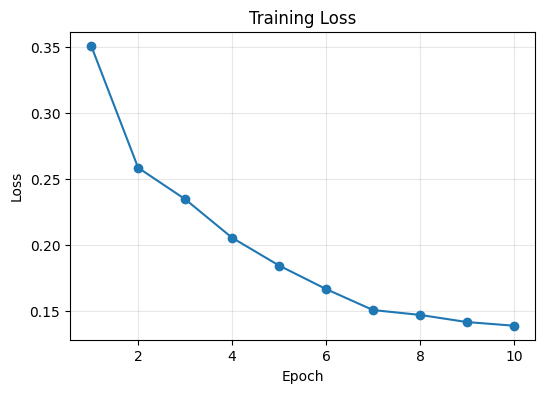

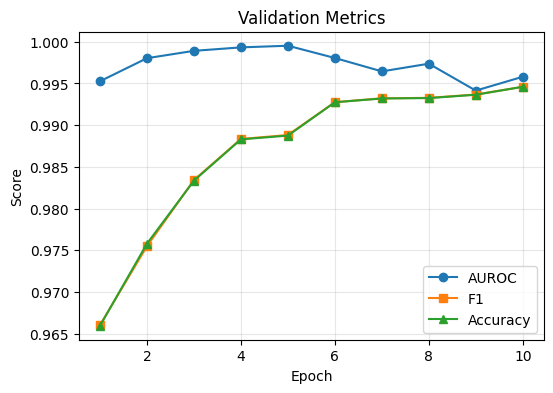

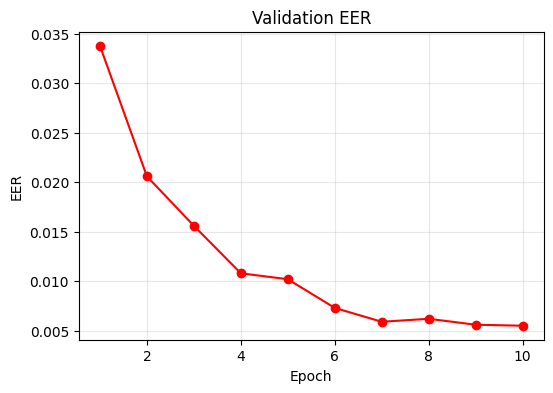

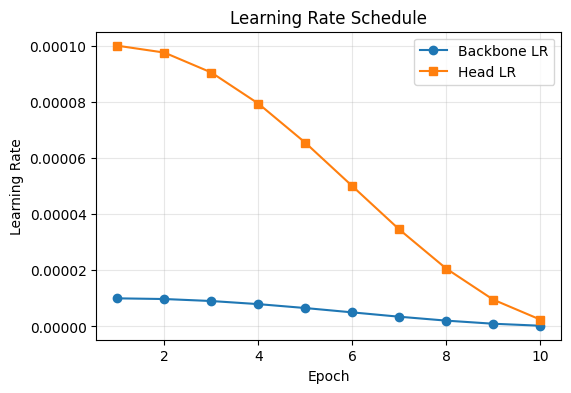

In [13]:
plot_stage3_curves(
    train_loss_list,
    val_auc_list,
    val_f1_list,
    val_acc_list,
    val_eer_list,
    lr_backbone_list,
    lr_head_list
)


## 8. Conclusion
This pretraining stage demonstrates that the proposed Stage 3 architecture can learn highly discriminative fake/real representations from aligned facial images. Since this stage focuses only on detection, no localisation visualisations are included. Localisation is introduced and analysed separately in the semantic-mask pretraining and fine-tuning stages.
